In [1]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
import plotly.express as px

from plotnine import *

from datetime import date, datetime

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


### Bulk Queries

In [7]:
# Read from the 'churn_state' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.posthog_aggregated_dev.user_churn_state`
"""
churn_df = bq.query(query).to_dataframe()

query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.users`
"""
users_df = bq.query(query).to_dataframe()

### Churn Stats

In [8]:
#showing never active based on app is web user or user who was active prior to Jan 1st
never_active = churn_df[(churn_df['app_churn_state'] == 'never_active')]
never_active = never_active.merge(users_df[['user_id', 'username']], on='user_id', how='left')

print(f"Users who were never active in the app: {len(never_active)}")
print(f"Users who do not have ios accounts: {never_active[never_active['username'].isna()].shape[0]}")
print(f"Users who most likely used app prior to start_date: {never_active[never_active['username'].notna()].shape[0]}")

Users who were never active in the app: 418
Users who do not have ios accounts: 364
Users who most likely used app prior to start_date: 54


In [9]:
#Churn Rate Metrics
# Overall churn rates
filtered_churn_df = churn_df[~(churn_df['app_churn_state'] == 'never_active')]
app_churn_rate = (filtered_churn_df['app_churn_state'] == 'churned').sum() / len(filtered_churn_df) * 100
biz_churn_rate = (filtered_churn_df['biz_churn_state'] == 'churned').sum() / len(filtered_churn_df) * 100

# Reactivation rate
app_reactivation_rate = (filtered_churn_df['app_churn_state'] == 'reactivated').sum() / len(filtered_churn_df) * 100
biz_reactivation_rate = (filtered_churn_df['biz_churn_state'] == 'reactivated').sum() / len(filtered_churn_df) * 100

print(f"App Activity Churn Rate: {app_churn_rate:.2f}%")
print(f"App Activity Usage Resurrection Rate: {app_reactivation_rate:.2f}%")

print(f"Event/Joiner Churn Rate: {biz_churn_rate:.2f}%")
print(f"Event/Joiner Resurrection Rate: {biz_reactivation_rate:.2f}%")

App Activity Churn Rate: 44.22%
App Activity Usage Resurrection Rate: 4.76%
Event/Joiner Churn Rate: 33.33%
Event/Joiner Resurrection Rate: 3.40%


In [10]:
# Churn time metrics
# Average days since last activity (for churned users)
churn_df['app_churn_date'] = pd.to_datetime(churn_df['app_churn_date'])
churn_df['biz_churn_date'] = pd.to_datetime(churn_df['biz_churn_date'])
churn_df['first_app_active_date'] = pd.to_datetime(churn_df['first_app_active_date'])
churn_df['first_biz_active_date'] = pd.to_datetime(churn_df['first_biz_active_date'])

avg_days_inactive_app = churn_df[churn_df['app_churn_state'] == 'churned']['days_since_last_app_activity'].mean()
avg_days_inactive_biz = churn_df[churn_df['biz_churn_state'] == 'churned']['days_since_last_biz_activity'].mean()

# Time to churn (first activity to churn date)
churn_df['app_days_to_churn'] = (churn_df['app_churn_date'] - churn_df['first_app_active_date']).dt.days
churn_df['biz_days_to_churn'] = (churn_df['biz_churn_date'] - churn_df['first_biz_active_date']).dt.days

print(f"Average days since last app activity for churned users: {avg_days_inactive_app:.2f} days")
print(f"Average days since last business activity for churned users: {avg_days_inactive_biz:.2f} days")
print(f"Average days to churn from first app activity: {churn_df[churn_df['app_churn_state'] == 'churned']['app_days_to_churn'].mean():.2f} days")
print(f"Average days to churn from first business activity: {churn_df[churn_df['biz_churn_state'] == 'churned']['biz_days_to_churn'].mean():.2f} days")

Average days since last app activity for churned users: 29.18 days
Average days since last business activity for churned users: 64.44 days
Average days to churn from first app activity: 19.40 days
Average days to churn from first business activity: 19.55 days


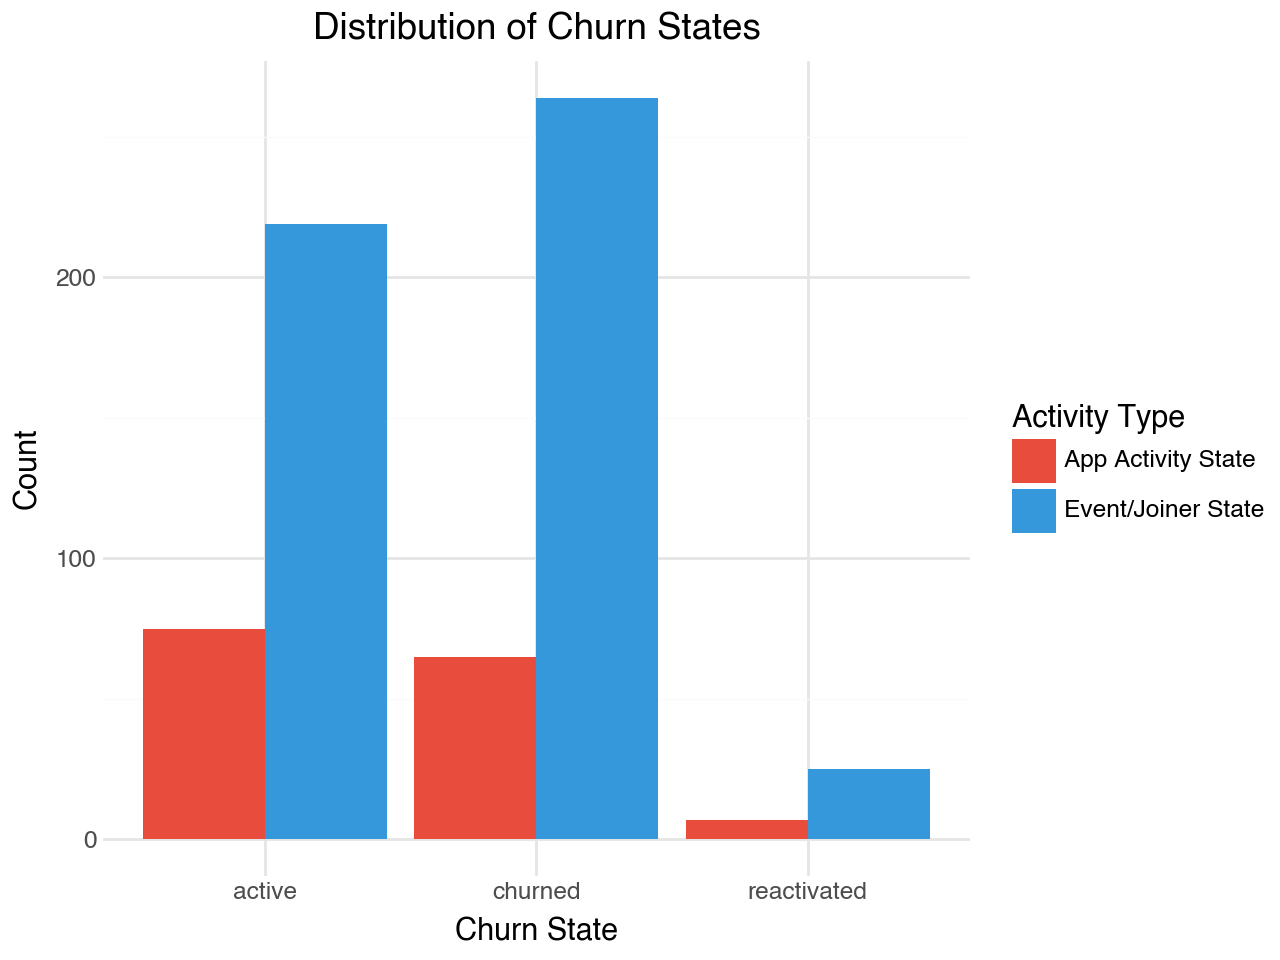

In [11]:
graph_df = churn_df.melt(id_vars=['user_id'], value_vars=['app_churn_state', 'biz_churn_state'], var_name='churn_type', value_name='churn_state')
graph_df = graph_df[graph_df['churn_state'] != 'never_active']

# Rename the churn_type values for better legend labels
graph_df['churn_type'] = graph_df['churn_type'].replace({
    'app_churn_state': 'App Activity State',
    'biz_churn_state': 'Event/Joiner State'
})

barplot = (ggplot(graph_df, aes(x='churn_state', fill='churn_type')) +
           geom_bar(position='dodge') +
           scale_fill_manual(values=['#e74c3c', '#3498db']) +  # Red and blue for distinct contrast
           labs(title='Distribution of Churn States', x='Churn State', y='Count', fill='Activity Type') +
           theme_minimal())

barplot.show()

In [12]:
# Cohort Retention Analysis - Weekly Cohorts (Percentage-Based)
# Remove users who were never active in business activities
cohort_analysis_df = churn_df[churn_df['biz_churn_state'] != 'never_active'].copy()

# Create cohorts based on first activity week
cohort_analysis_df['first_biz_active_date'] = pd.to_datetime(cohort_analysis_df['first_biz_active_date'])
cohort_analysis_df['last_biz_active_date'] = pd.to_datetime(cohort_analysis_df['last_biz_active_date'])

# Use week number instead of month - format as "YYYY-Wxx"
cohort_analysis_df['cohort_week'] = cohort_analysis_df['first_biz_active_date'].dt.strftime('%Y-W%U')

# Calculate weeks active instead of months
cohort_analysis_df['weeks_active'] = (cohort_analysis_df['last_biz_active_date'] - 
                                       cohort_analysis_df['first_biz_active_date']).dt.days // 7

# Get cohort sizes
cohort_sizes = cohort_analysis_df.groupby('cohort_week').size()

# Create retention matrix with absolute counts
retention_counts = cohort_analysis_df.groupby(['cohort_week', 'weeks_active']).size().unstack(fill_value=0)

# Convert to percentages
retention_pct = retention_counts.div(cohort_sizes, axis=0) * 100

# Ensure all weeks 0-6 are present as columns
for week in range(7):
    if week not in retention_pct.columns:
        retention_pct[week] = 0

# Sort columns to ensure proper order
retention_pct = retention_pct.sort_index(axis=1)

# Calculate max possible weeks for each cohort
end_date_dt = pd.to_datetime('2026-02-13')
cohort_first_dates = cohort_analysis_df.groupby('cohort_week')['first_biz_active_date'].min()
max_weeks_elapsed = ((end_date_dt - cohort_first_dates).dt.days // 7).to_dict()

# Mask impossible retention periods (set to NaN)
retention_pct_masked = retention_pct.copy()
for cohort in retention_pct_masked.index:
    max_weeks = max_weeks_elapsed.get(cohort, 0)
    # Set all columns beyond the max possible weeks to NaN
    cols_to_mask = [col for col in retention_pct_masked.columns if col > max_weeks]
    retention_pct_masked.loc[cohort, cols_to_mask] = np.nan

# Create plots with masked data
fig = px.imshow(
    retention_pct_masked,
    title='Cohort Retention Heatmap - Event/Joiner Activity (% of Cohort) - Weekly',
    labels=dict(x='Weeks Since First Activity', y='Cohort Week', color='Retention %'),
    aspect='auto',
    color_continuous_scale='RdYlGn',
    text_auto='.1f'
)
fig.update_layout(yaxis_title=None)
fig.show()

In [47]:
# Cohort Retention Analysis - Weekly Cohorts (Percentage-Based)
# Remove users who were never active in app activity
cohort_analysis_df = churn_df[churn_df['app_churn_state'] != 'never_active'].copy()

# Create cohorts based on first activity week
cohort_analysis_df['first_app_active_date'] = pd.to_datetime(cohort_analysis_df['first_app_active_date'])
cohort_analysis_df['last_app_active_date'] = pd.to_datetime(cohort_analysis_df['last_app_active_date'])
# Use week number instead of month - format as "YYYY-Wxx"
cohort_analysis_df['cohort_week'] = cohort_analysis_df['first_app_active_date'].dt.strftime('%Y-W%U')

# Calculate weeks active instead of months
cohort_analysis_df['weeks_active'] = (cohort_analysis_df['last_app_active_date'] - 
                                       cohort_analysis_df['first_app_active_date']).dt.days // 7

# Get cohort sizes
cohort_sizes = cohort_analysis_df.groupby('cohort_week').size()

# Create retention matrix with absolute counts
retention_counts = cohort_analysis_df.groupby(['cohort_week', 'weeks_active']).size().unstack(fill_value=0)

# Convert to percentages
retention_pct = retention_counts.div(cohort_sizes, axis=0) * 100

# Ensure all weeks 0-6 are present as columns
for week in range(7):
    if week not in retention_pct.columns:
        retention_pct[week] = 0

# Sort columns to ensure proper order
retention_pct = retention_pct.sort_index(axis=1)

# Calculate max possible weeks for each cohort
end_date_dt = pd.to_datetime('2026-02-13')
cohort_first_dates = cohort_analysis_df.groupby('cohort_week')['first_app_active_date'].min()
max_weeks_elapsed = ((end_date_dt - cohort_first_dates).dt.days // 7).to_dict()

# Mask impossible retention periods (set to NaN)
retention_pct_masked = retention_pct.copy()
for cohort in retention_pct_masked.index:
    max_weeks = max_weeks_elapsed.get(cohort, 0)
    # Set all columns beyond the max possible weeks to NaN
    cols_to_mask = [col for col in retention_pct_masked.columns if col > max_weeks]
    retention_pct_masked.loc[cohort, cols_to_mask] = np.nan

# Create plots with masked data
fig = px.imshow(
    retention_pct_masked,
    title='Cohort Retention Heatmap - App Activity (% of Cohort) - Weekly',
    labels=dict(x='Weeks Since First Activity', y='Cohort Week', color='Retention %'),
    aspect='auto',
    color_continuous_scale='RdYlGn',
    text_auto='.1f'
)
fig.update_layout(yaxis_title=None)
fig.show()